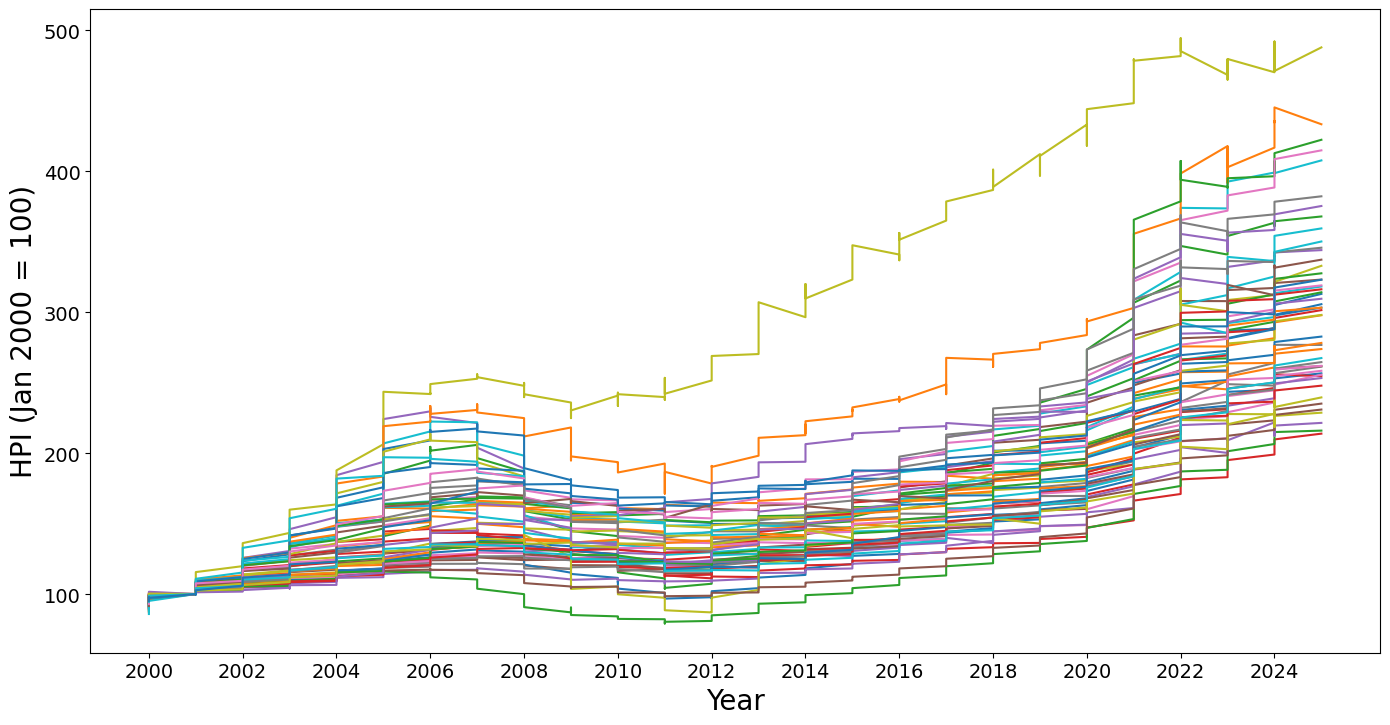

In [65]:
import pandas as pd
import matplotlib.pyplot as plt


csv_file_path = 'MacroData/StateMacros.csv'
df = pd.read_csv(csv_file_path)
df.columns = ['State', 'YearMonth', 'UnemploymentRate', 'HPI']
df = df[(df['YearMonth'] >= 200001)]
df['Month'] = df['YearMonth'] % 100
df = df[df['Month'].isin([1, 4, 7, 10])]


norm_factors = {}

states = df['State'].unique()
for state in states:
    jan_2001_hpi = df[(df['State'] == state) & (df['YearMonth'] == 200101)]['HPI']
    if not jan_2001_hpi.empty:
        norm_factors[state] = jan_2001_hpi.values[0]

def normalize(row):
    state = row['State']
    if state in norm_factors:
        return (row['HPI'] / norm_factors[state]) * 100
    else:
        return None

df['Normalized_HPI'] = df.apply(normalize, axis=1)

df['Year'] = df['YearMonth'] // 100

fig, ax = plt.subplots(figsize=(14, 8))
for state in states:
    state_df = df[df['State'] == state]
    if state_df['Normalized_HPI'].notnull().any():
        ax.plot(state_df['Year'], state_df['Normalized_HPI'], label=state)

ax.set_xlabel('Year', fontsize=20)
ax.set_ylabel('HPI (Jan 2000 = 100)', fontsize=20)

years_to_show = list(range(2000, 2026, 2))  
ax.set_xticks(years_to_show)
ax.set_xticklabels(years_to_show, fontsize=14)

ax.tick_params(axis='y', labelsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig('Charts/StateHPIChart.png', dpi=300)

plt.show()

In [36]:
import pandas as pd
import os

# Assume root directory is './TrainingData'
root_dir = './TrainingData'

performance_counts = []

# Load in all files from TrainingData Folder
for year_folder in sorted(os.listdir(root_dir)):
    year_path = os.path.join(root_dir, year_folder)
    origcounts = []
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                num_active = len(df["Loan Sequence Number"].unique())
                num_stressed = len(df[(df["Major Stress"] == 1)]["Loan Sequence Number"].unique())
                num_default = len(df[(df["Default Flag"] == 1)]["Loan Sequence Number"].unique())

                origcounts.append((num_active, num_stressed, num_default))
    performance_counts.append(origcounts)

In [37]:
for i in range(len(performance_counts)):
    print("Performance Year: ", i+2000)
    print(performance_counts[i])

Performance Year:  2000
[(40621, 76, 51)]
Performance Year:  2001
[(39553, 220, 121), (43193, 68, 47)]
Performance Year:  2002
[(21513, 196, 123), (44534, 153, 94), (44383, 84, 62)]
Performance Year:  2003
[(10098, 131, 82), (24909, 126, 87), (37306, 120, 81), (44175, 17, 12)]
Performance Year:  2004
[(5132, 98, 55), (13552, 101, 60), (24966, 105, 72), (45551, 57, 41), (43349, 29, 20)]
Performance Year:  2005
[(3569, 66, 32), (9988, 80, 37), (19640, 95, 44), (40099, 72, 30), (45417, 97, 53), (43988, 34, 17)]
Performance Year:  2006
[(2749, 37, 17), (7995, 51, 27), (16614, 87, 52), (35531, 69, 32), (40345, 129, 72), (46421, 107, 67), (42370, 41, 28)]
Performance Year:  2007
[(2276, 44, 15), (6926, 55, 38), (14815, 64, 29), (32550, 86, 53), (36446, 167, 103), (42611, 316, 211), (45996, 349, 252), (43130, 200, 164)]
Performance Year:  2008
[(1965, 47, 22), (6033, 86, 40), (13302, 110, 55), (30066, 164, 83), (33529, 336, 181), (39158, 706, 468), (41071, 994, 652), (45894, 1067, 720), (4363

In [38]:
stress_props = []
default_props = []

for perf_year in performance_counts:

    num_active, num_stressed, num_default = 0, 0, 0

    for orig_year in perf_year:
        num_active+= orig_year[0]
        num_stressed+= orig_year[1]
        num_default+= orig_year[2]
    
    stress_props.append(num_stressed / num_active)
    default_props.append(num_default / num_active)




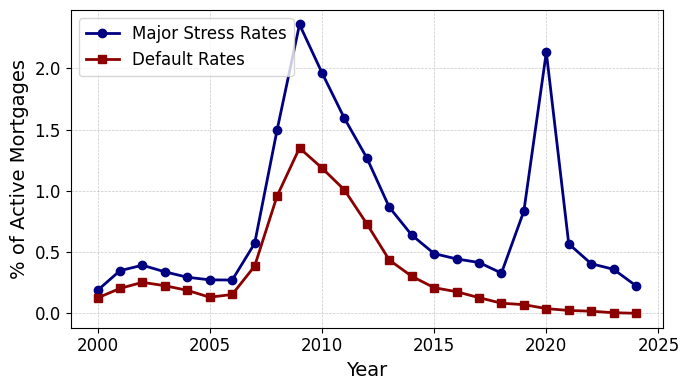

In [64]:
import matplotlib.pyplot as plt

# Create a figure with size 14x8
plt.figure(figsize=(7, 4))

# Plot the first line (deep blue) with markers
plt.plot(
    range(2000, 2025), 
    [x * 100 for x in stress_props], 
    label='Major Stress Rates',
    color='navy',        # professional deep blue
    marker='o',          # circle markers
    markersize=6,        # slightly larger markers
    linewidth=2          # thicker line
)

# Plot the second line (dark red) with markers
plt.plot(
    range(2000, 2025), 
    [x * 100 for x in default_props], 
    label='Default Rates',
    color='darkred',     # professional dark red
    marker='s',          # square markers for contrast
    markersize=6,
    linewidth=2
)

# Add labels and title
plt.xlabel('Year', fontsize=14)
plt.ylabel('% of Active Mortgages', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)  # subtle grid

# Make ticks a bit larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Tight layout for better spacing
plt.tight_layout()

plt.savefig('Charts/COVIDStimi.png', dpi=300)
plt.show()



In [89]:
import pandas as pd
import os

# Assume root directory is './TrainingData'
root_dir = './TrainingData'

performance_counts = []

ChartList = []

# Load in all files from TrainingData Folder
for year in range(2000, 2018+1):
    year_path = os.path.join(root_dir, f"Year{year}")
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                df = df[(df["Major Stress"] == 1)][["Default Flag", "Original UPB", "Original Combined Loan-to-Value (CLTV)", 
                                                    "HPI Change %", "Current Actual UPB", "Actual Loss Calculation", "Zero Balance Removal UPB", 
                                                    "Net Sales Proceeds", "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]]

                ChartList.append(df) 

Chart = pd.concat(ChartList).reset_index(drop=True)

In [121]:
Chart["Estimated Value at Origination"] = Chart["Original UPB"] / (Chart["Original Combined Loan-to-Value (CLTV)"] / 100)
Chart["Estimated Current Value"] = Chart["Estimated Value at Origination"] * (Chart["HPI Change %"] + 1)

Chart["Imputed Estimated LTV"] = Chart["Current Actual UPB"] / Chart["Estimated Current Value"]

Chart["LGD"] = Chart["Actual Loss Calculation"] / Chart["Zero Balance Removal UPB"]
Chart["Other LGD"] =  (Chart["Actual Loss Calculation"] - Chart["MI Recoveries"]) / Chart["Zero Balance Removal UPB"]

In [118]:
Chart[Chart["Default Flag"] == 1]

,Default Flag,Original UPB,Original Combined Loan-to-Value (CLTV),HPI Change %,Current Actual UPB,Actual Loss Calculation,Zero Balance Removal UPB,Net Sales Proceeds,Delinquent Accrued Interest,Expenses,MI Recoveries,Non MI Recoveries,Estimated Value at Origination,Estimated Current Value,Imputed Estimated LTV,LGD,LTV Bucket,Regionally Estimated Loan-to-Value
0,1.0,128000,95,0.0,128000.0,NaN,127722.09,NaN,NaN,NaN,NaN,NaN,134736.842105,134736.842105,0.950000,NaN,90-100%,90-100%
2,1.0,84000,97,0.0,84000.0,-1161.87,83786.21,86547.48,8012.06,-5078.66,8478.80,688.78,86597.938144,86597.938144,0.970000,-0.013867,90-100%,90-100%
3,1.0,24000,80,0.0,24000.0,-19067.65,23792.09,12154.03,2908.58,-4906.74,0.00,385.73,30000.000000,30000.000000,0.800000,-0.801428,80-90%,80-90%
6,1.0,43000,95,0.0,43000.0,0.00,42750.00,0.00,0.00,0.00,0.00,0.00,45263.157895,45263.157895,0.950000,0.000000,90-100%,90-100%
9,1.0,48000,74,0.0,48000.0,-20642.16,47619.02,35262.77,4458.33,-4035.85,0.00,208.27,64864.864865,64864.864865,0.740000,-0.433486,70-80%,70-80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36310,1.0,99000,80,0.0,98000.0,0.00,98283.88,0.00,0.00,0.00,0.00,0.00,123750.000000,123750.000000,0.791919,0.000000,70-80%,70-80%
36315,1.0,57000,95,0.0,57000.0,-7708.54,56685.18,47261.84,4200.37,-11405.67,16766.41,554.43,60000.000000,60000.000000,0.950000,-0.135989,90-100%,90-100%
36317,1.0,110000,90,0.0,110000.0,-13472.80,109619.47,113025.00,5818.97,-13855.64,0.00,2796.28,122222.222222,122222.222222,0.900000,-0.122905,90-100%,90-100%
36320,1.0,155000,68,0.0,155000.0,-8126.80,153779.46,176089.79,11168.23,-21974.86,0.00,2705.96,227941.176471,227941.176471,0.680000,-0.052847,60-70%,60-70%


C:\Users\matth\AppData\Local\Temp\ipykernel_11624\4135515841.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts = Chart.groupby(['Regionally Estimated Loan-to-Value', 'Default Flag']).size().unstack(fill_value=0)
C:\Users\matth\AppData\Local\Temp\ipykernel_11624\4135515841.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_lgd_preMI = Chart[Chart["Default Flag"] == 1].groupby('Regionally Estimated Loan-to-Value')['Other LGD'].median() * -1
C:\Users\matth\AppData\Local\Temp\ipykernel_11624\4135515841.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to

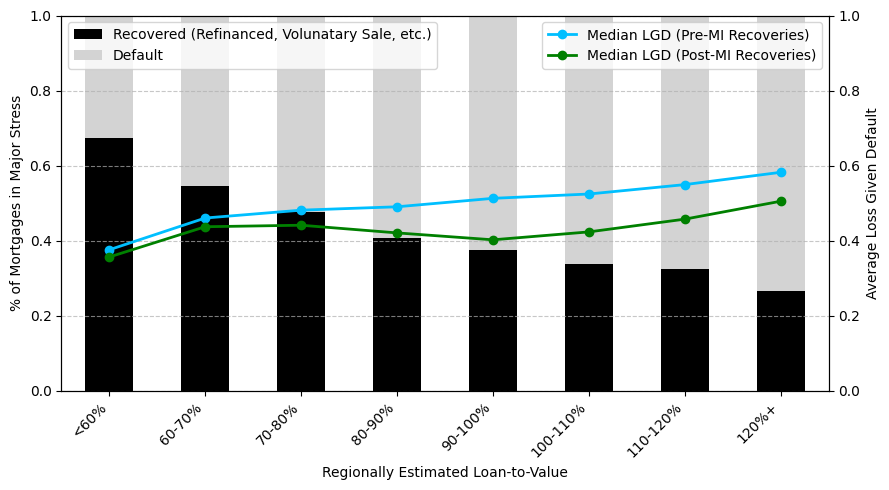

In [133]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df
# and columns are similar to what you showed

# Example: load your dataframe (replace this with your own loading if needed)
# df = pd.read_csv('your_data.csv')

# Define LTV buckets
bins = [0, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 2.0]
labels = ['<60%', '60-70%', '70-80%', '80-90%', '90-100%', '100-110%', '110-120%', '120%+']
Chart['Regionally Estimated Loan-to-Value'] = pd.cut(Chart['Imputed Estimated LTV'], bins=bins, labels=labels, right=False)

# Group and count defaults and non-defaults
grouped_counts = Chart.groupby(['Regionally Estimated Loan-to-Value', 'Default Flag']).size().unstack(fill_value=0)
grouped_props = grouped_counts.div(grouped_counts.sum(axis=1), axis=0)



# Calculate average LGD per bucket
med_lgd_preMI = Chart[Chart["Default Flag"] == 1].groupby('Regionally Estimated Loan-to-Value')['Other LGD'].median() * -1
med_lgd = Chart[Chart["Default Flag"] == 1].groupby('Regionally Estimated Loan-to-Value')['LGD'].median() * -1


fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart (default and non-default proportions)
grouped_props.plot(kind='bar', stacked=True, ax=ax1, color=['black', 'lightgrey'])

ax1.set_ylabel("% of Mortgages in Major Stress")
ax1.set_ylim(0, 1)  # Left y-axis from 0 to 1
ax1.legend(["Recovered (Refinanced, Volunatary Sale, etc.)", "Default"], loc="upper left")
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Line plot for average LGD
ax2 = ax1.twinx()
ax2.plot(med_lgd_preMI.index, med_lgd_preMI.values, color='deepskyblue', marker='o', linewidth=2, label='Median LGD (Pre-MI Recoveries)')
ax2.plot(med_lgd.index, med_lgd.values, color='green', marker='o', linewidth=2, label='Median LGD (Post-MI Recoveries)')
ax2.set_ylabel("Average Loss Given Default")
ax2.set_ylim(0, 1)  # Right y-axis from 0 to 1
ax2.legend(loc="upper right")

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Charts/ImpactOfLTV")
plt.show()